# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [3]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [4]:
import pandas as pd

matches_df_train = pd.read_csv('matches_df_train.csv')
matches_df_test = pd.read_csv('matches_df_test.csv')

# (´-`）.｡oO( ... YOUR CODE HERE ... )

In [5]:
print(f"Размер тренировочной выборки: {matches_df_train.memory_usage(deep=True).sum() / 1024**2}Мб, число строк и столбцов: {matches_df_train.shape}")
print(f"Размер тестовой выборки: {matches_df_test.memory_usage(deep=True).sum() / 1024**2}Мб, число строк и столбцов: {matches_df_test.shape}")

Размер тренировочной выборки: 92.50748825073242Мб, число строк и столбцов: (641090, 7)
Размер тестовой выборки: 8.0858793258667Мб, число строк и столбцов: (59748, 5)


In [6]:
matches_df_train.head()

,match_id,date,region,game_mode,duration,radiant_win,avg_mmr
0,1,2024-02-12,Europe West,4,2625,False,3519.7
1,2,2024-04-08,South Africa,2,7526,True,2330.9
2,3,2024-06-16,SE Asia,1,2831,True,1579.6
3,4,2024-09-16,Middle East,22,1438,False,NaN
4,5,2024-03-31,South Africa,22,2051,True,NaN


In [7]:
matches_df_test.head()

,match_id,date,region,game_mode,avg_mmr
0,8,2024-12-01,China,1,2305.0
1,29,2024-12-17,Europe West,22,NaN
2,34,2024-12-19,Europe West,22,2278.5
3,36,2024-12-19,Europe West,1,305.8
4,61,2024-12-06,Australia,1,5142.4


Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

In [8]:
print(matches_df_train['radiant_win'].value_counts(normalize=True).mul(100).round(2))

radiant_win
True     51.08
False    48.92
Name: proportion, dtype: float64


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** Так как распределние практически одинаковое, то Gini подойдет лучше, чем AUC-PR
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

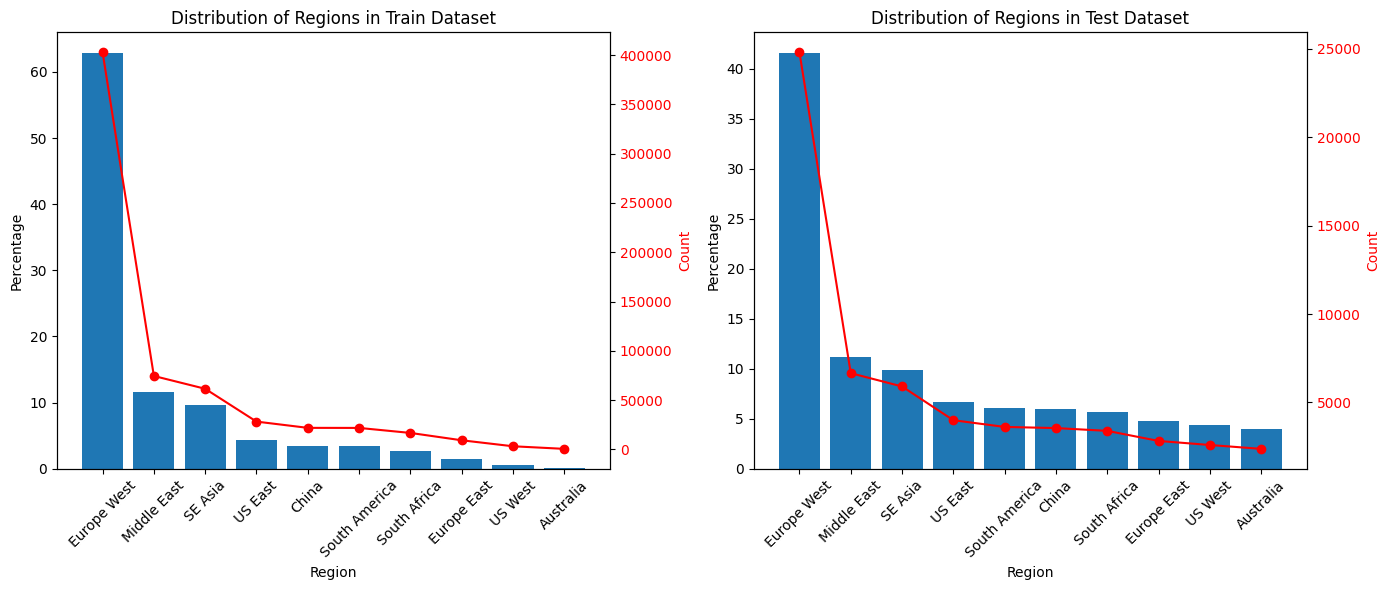

In [9]:
import matplotlib.pyplot as plt

r = matches_df_train['region'].value_counts(normalize=True).mul(100).round(2)
r1 = matches_df_train['region'].value_counts(normalize=False)

t = matches_df_test['region'].value_counts(normalize=True).mul(100).round(2)
t1 = matches_df_test['region'].value_counts(normalize=False)

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

axes[0].bar(r.index, r.values)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Percentage')
axes[0].set_title('Distribution of Regions in Train Dataset')
axes[0].tick_params(axis='x', rotation=45)

a = axes[0].twinx()
a.plot(r1.index, r1.values, color='red', marker='o')
a.set_ylabel('Count', color='red')
a.tick_params(axis='y', labelcolor='red')

axes[1].bar(t.index, t.values)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Distribution of Regions in Test Dataset')
axes[1].tick_params(axis='x', rotation=45)

b = axes[1].twinx()
b.plot(t1.index, t1.values, color='red', marker='o')
b.set_ylabel('Count', color='red')
b.tick_params(axis='y', labelcolor='red')


plt.tight_layout()
plt.show()

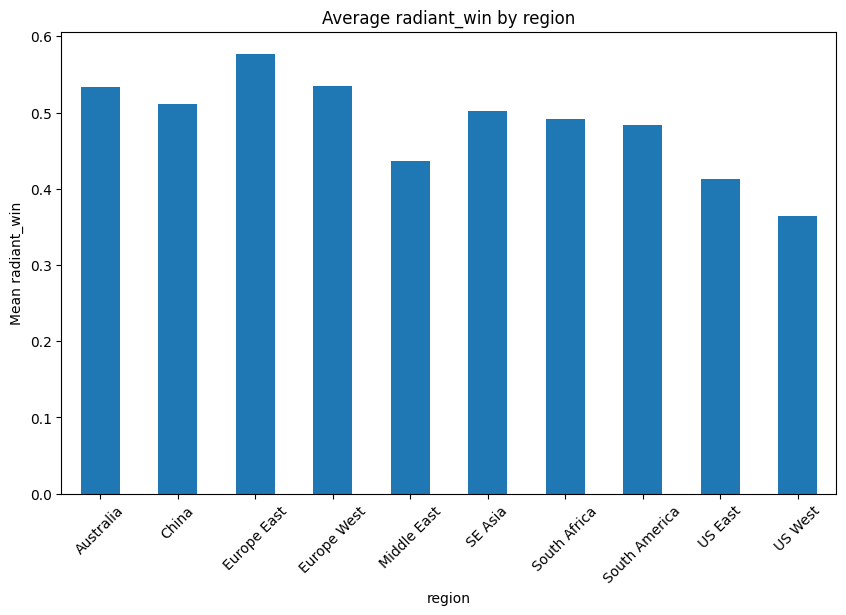

In [10]:
target_by_region = matches_df_train.groupby('region')['radiant_win'].mean()

plt.figure(figsize=(10,6))

target_by_region.plot(kind='bar')

plt.title('Average radiant_win by region')
plt.ylabel('Mean radiant_win')
plt.xticks(rotation=45)

plt.show()

In [11]:
print(r)

region
Europe West      62.85
Middle East      11.63
SE Asia           9.60
US East           4.41
China             3.42
South America     3.41
South Africa      2.62
Europe East       1.45
US West           0.51
Australia         0.10
Name: proportion, dtype: float64


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**  Распределение регионов неравномерное, основное количество матей приходится на Europe West. Модель обучить получитс, так как по данных по регионам с наибольшим количеством матчей достаточно, а сами регионы легко закодировать. Сигнала может не быть в том случае, если для каждого из регионов распределение целевой переменной примерно одинаково
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

In [12]:
!pip install -qU category-encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** На мой взгляд наиболее привлекательным является One-Hot encoder, так как для меня он более интуитивен, нежели например Target Encoder, который кодирует признак через значения целевой переменной
</div>

Закодируйте колонку `region` выбранным вами способом

In [13]:
import category_encoders as ce

encoder = ce.OneHotEncoder(cols=['region'])

train_encoded = encoder.fit_transform(matches_df_train['region'])
test_encoded = encoder.transform(matches_df_test['region'])

matches_df_test.drop(columns=['region'])
matches_df_train.drop(columns=['region'])

matches_df_test = pd.concat([matches_df_test, test_encoded], axis=1)
matches_df_train = pd.concat([matches_df_train, train_encoded], axis=1)
matches_df_test.head()


,match_id,date,region,game_mode,avg_mmr,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10
0,8,2024-12-01,China,1,2305.0,0,0,0,0,0,0,0,1,0,0
1,29,2024-12-17,Europe West,22,NaN,1,0,0,0,0,0,0,0,0,0
2,34,2024-12-19,Europe West,22,2278.5,1,0,0,0,0,0,0,0,0,0
3,36,2024-12-19,Europe West,1,305.8,1,0,0,0,0,0,0,0,0,0
4,61,2024-12-06,Australia,1,5142.4,0,0,0,0,0,0,0,0,0,1


#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

In [14]:
matches_df_train.head()

,match_id,date,region,game_mode,duration,radiant_win,avg_mmr,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10
0,1,2024-02-12,Europe West,4,2625,False,3519.7,1,0,0,0,0,0,0,0,0,0
1,2,2024-04-08,South Africa,2,7526,True,2330.9,0,1,0,0,0,0,0,0,0,0
2,3,2024-06-16,SE Asia,1,2831,True,1579.6,0,0,1,0,0,0,0,0,0,0
3,4,2024-09-16,Middle East,22,1438,False,NaN,0,0,0,1,0,0,0,0,0,0
4,5,2024-03-31,South Africa,22,2051,True,NaN,0,1,0,0,0,0,0,0,0,0


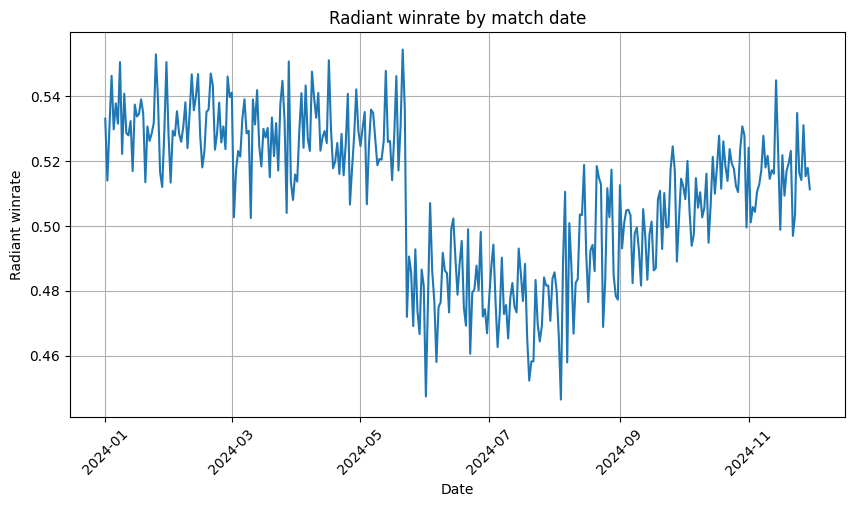

In [15]:
import matplotlib.pyplot as plt

matches_df_train['date'] = pd.to_datetime(matches_df_train['date'])
radiant_by_date = matches_df_train.groupby('date')['radiant_win'].mean()
plt.figure(figsize=(10,5))
plt.plot(radiant_by_date.index, radiant_by_date.values)
plt.title("Radiant winrate by match date")
plt.xlabel("Date")
plt.ylabel("Radiant winrate")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [16]:
matches_df_train.head()

,match_id,date,region,game_mode,duration,radiant_win,avg_mmr,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,region_10
0,1,2024-02-12,Europe West,4,2625,False,3519.7,1,0,0,0,0,0,0,0,0,0
1,2,2024-04-08,South Africa,2,7526,True,2330.9,0,1,0,0,0,0,0,0,0,0
2,3,2024-06-16,SE Asia,1,2831,True,1579.6,0,0,1,0,0,0,0,0,0,0
3,4,2024-09-16,Middle East,22,1438,False,NaN,0,0,0,1,0,0,0,0,0,0
4,5,2024-03-31,South Africa,22,2051,True,NaN,0,1,0,0,0,0,0,0,0,0


In [17]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** В конце мая-начале июня 2024го изменился баланс сил, и винрейт радианта упал. Скорее всего это связано с патчем 7.36b, в котором были изменены некоторые характеристики героев и предметов.

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** Я добавил признаки: месяц и является ли день выходным. Мне кажется это может сработать в связи с тем, что в некоторые месяца люди чаще берут отпуска, в выходные люди чаще играют, но скорее всего это не внесет серьезного вклада. Мне кажется, что нужно кодировать числами такие признаки как месяц, день недели и подобные.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [18]:
matches_df_test['date'] = pd.to_datetime(matches_df_test['date'])

matches_df_train['day'] = matches_df_train['date'].dt.day
matches_df_train['weekday'] = matches_df_train['date'].dt.weekday

matches_df_test['day'] = matches_df_test['date'].dt.day
matches_df_test['weekday'] = matches_df_test['date'].dt.weekday

matches_df_test['month'] = matches_df_test['date'].dt.month
matches_df_train['month'] = matches_df_train['date'].dt.month

matches_df_train['is_weekend'] = matches_df_train['weekday'].isin([5,6]).astype(int)
matches_df_test['is_weekend'] = matches_df_test['weekday'].isin([5,6]).astype(int)

matches_df_train.head()

,match_id,date,region,game_mode,duration,radiant_win,avg_mmr,region_1,region_2,region_3,...,region_5,region_6,region_7,region_8,region_9,region_10,day,weekday,month,is_weekend
0,1,2024-02-12,Europe West,4,2625,False,3519.7,1,0,0,...,0,0,0,0,0,0,12,0,2,0
1,2,2024-04-08,South Africa,2,7526,True,2330.9,0,1,0,...,0,0,0,0,0,0,8,0,4,0
2,3,2024-06-16,SE Asia,1,2831,True,1579.6,0,0,1,...,0,0,0,0,0,0,16,6,6,1
3,4,2024-09-16,Middle East,22,1438,False,NaN,0,0,0,...,0,0,0,0,0,0,16,0,9,0
4,5,2024-03-31,South Africa,22,2051,True,NaN,0,1,0,...,0,0,0,0,0,0,31,6,3,1


Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Точно известно, что баланс сил сильно менялся с одним из патчей, и в целом распределение целевой переменной имеет колебания, так что данные имеют временную зависимость.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [19]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from sklearn.model_selection import train_test_split

matches_df_train = matches_df_train.sort_values('date')
matches_df_train.head()

X = matches_df_train.drop(columns=['radiant_win'])
y = matches_df_train['radiant_win']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    shuffle=False
)

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

date_features = ['day', 'weekday', 'month', 'is_weekend']
region_features = [col for col in X_train.columns if col.startswith('region_')]
date_region_features = date_features + region_features

model_dates = LogisticRegression(max_iter=1000)
model_dates.fit(X_train[date_features], y_train)
pred_dates = model_dates.predict_proba(X_val[date_features])[:,1]
auc_dates = roc_auc_score(y_val, pred_dates)
print("Gini for dates:", 2 * auc_dates - 1)

model_region = LogisticRegression(max_iter=1000)
model_region.fit(X_train[region_features], y_train)
pred_region = model_region.predict_proba(X_val[region_features])[:,1]
auc_region = roc_auc_score(y_val, pred_region)
print("Gini for region:", 2 * auc_region - 1)

model_region_data = LogisticRegression(max_iter=1000)
model_region_data.fit(X_train[date_region_features], y_train)
pred_region_date = model_region_data.predict_proba(X_val[date_region_features])[:,1]
auc_region_data = roc_auc_score(y_val, pred_region_date)
print("Gini for region:", 2 * auc_region_data - 1)


Gini for dates: -0.010449826695391518
Gini for region: 0.07588874964075298
Gini for region: 0.07132174712372708


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Даты не помогли, в целом они даже ухудшают модель, поэтому оставлять их не имеет смысла. Думаю они и нед должны были помочь, так как то, в какой день происходит матч, вряд ли должно влиять на его результат

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

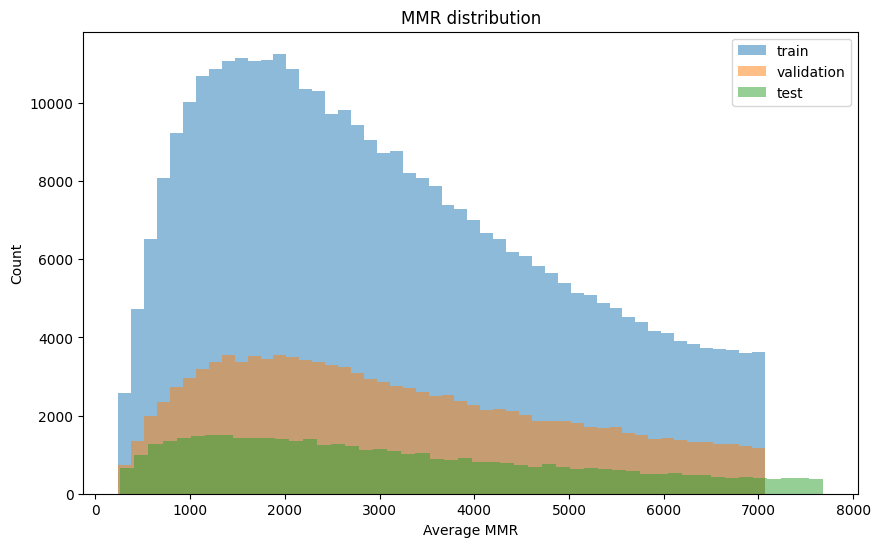

In [21]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

plt.figure(figsize=(10,6))

plt.hist(X_train['avg_mmr'], bins=50, alpha=0.5, label='train')
plt.hist(X_val['avg_mmr'], bins=50, alpha=0.5, label='validation')
plt.hist(matches_df_test['avg_mmr'], bins=50, alpha=0.5, label='test')

plt.xlabel("Average MMR")
plt.ylabel("Count")
plt.title("MMR distribution")

plt.legend()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** Распределение отдаленно похоже на сильно смещенное нормальное

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

In [22]:
import numpy as np



for df in [X_train, X_val, matches_df_test]:
    
    df['mmr_log'] = np.log1p(df['avg_mmr'])     
    df['mmr_sqrt'] = np.sqrt(df['avg_mmr'])      
    df['mmr_inv'] = 1 / (1 + df['avg_mmr'])      
    df['mmr_exp_log'] = np.exp(np.log(df['avg_mmr']))  


In [23]:
X_train.head()

,match_id,date,region,game_mode,duration,avg_mmr,region_1,region_2,region_3,region_4,...,region_9,region_10,day,weekday,month,is_weekend,mmr_log,mmr_sqrt,mmr_inv,mmr_exp_log
147802,176828,2024-01-01,Europe West,22,2206,NaN,1,0,0,0,...,0,0,1,0,1,0,NaN,NaN,NaN,NaN
442520,529827,2024-01-01,Middle East,1,3191,4391.5,0,0,0,1,...,0,0,1,0,1,0,8.387654,66.268394,0.000228,4391.5
274960,329224,2024-01-01,Europe West,1,1714,NaN,1,0,0,0,...,0,0,1,0,1,0,NaN,NaN,NaN,NaN
415926,497876,2024-01-01,Middle East,1,2441,NaN,0,0,0,1,...,0,0,1,0,1,0,NaN,NaN,NaN,NaN
451726,540899,2024-01-01,SE Asia,1,2001,5158.5,0,0,1,0,...,0,0,1,0,1,0,8.548595,71.822698,0.000194,5158.5


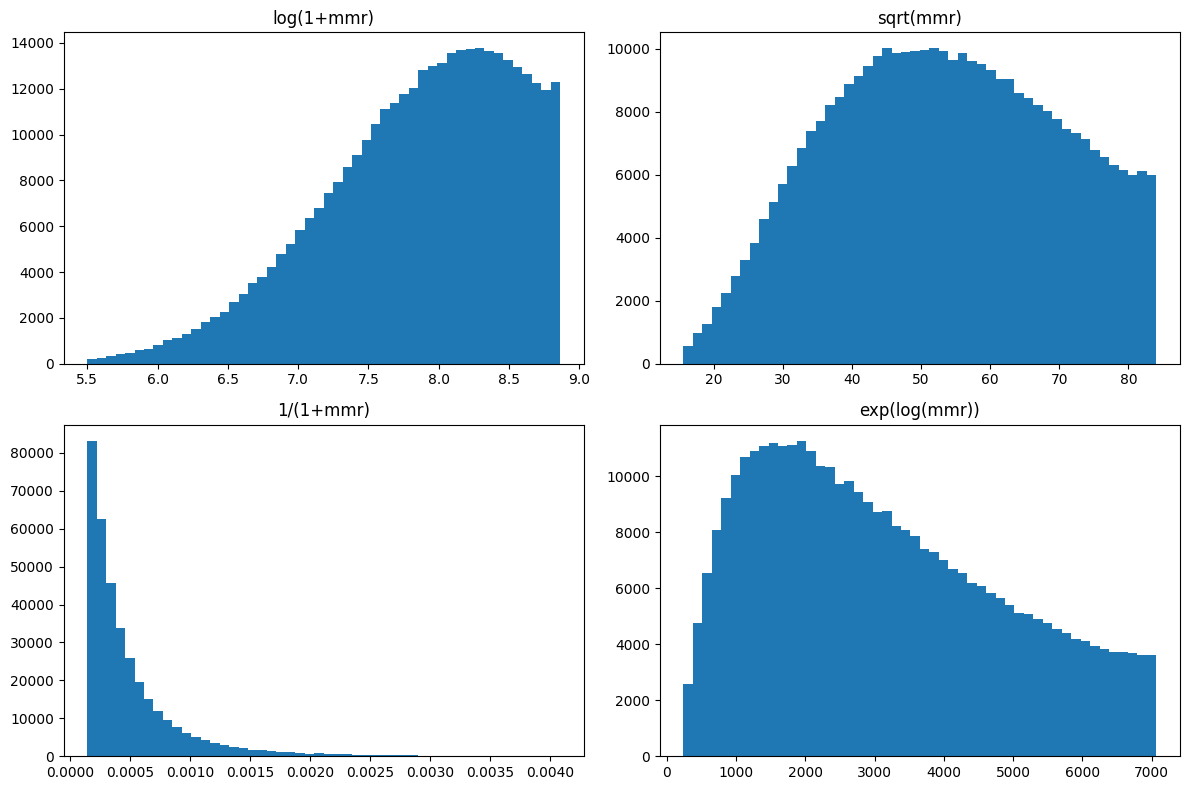

In [24]:

fig, axs = plt.subplots(2,2, figsize=(12,8))

axs[0,0].hist(X_train['mmr_log'].dropna(), bins=50)
axs[0,0].set_title("log(1+mmr)")

axs[0,1].hist(X_train['mmr_sqrt'].dropna(), bins=50)
axs[0,1].set_title("sqrt(mmr)")

axs[1,0].hist(X_train['mmr_inv'].dropna(), bins=50)
axs[1,0].set_title("1/(1+mmr)")

axs[1,1].hist(X_train['mmr_exp_log'].dropna(), bins=50)
axs[1,1].set_title("exp(log(mmr))")

plt.tight_layout()
plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Нет, так как ноль это далекое число от реального ммр игроков в матче, лучше всего заполнить пропуски медианным ммр.

</div>

In [25]:
for df in [X_train, X_val, matches_df_test]:
    df["mmr_missing"] = df["avg_mmr"].isna().astype(int)

mmr_median_train = X_train["avg_mmr"].median()
mmr_median_val = X_val["avg_mmr"].median()
mmr_median_test = matches_df_test["avg_mmr"].median()

X_train['avg_mmr'] = X_train["avg_mmr"].fillna(mmr_median_train)
X_val['avg_mmr'] = X_val["avg_mmr"].fillna(mmr_median_val)
matches_df_test['avg_mmr'] = matches_df_test["avg_mmr"].fillna(mmr_median_test)

for df in [X_train, X_val, matches_df_test]:
    
    df['mmr_log'] = np.log1p(df['avg_mmr'])     
    df['mmr_sqrt'] = np.sqrt(df['avg_mmr'])      
    df['mmr_inv'] = 1 / (1 + df['avg_mmr'])      
    df['mmr_exp_log'] = np.exp(np.log(df['avg_mmr']))  

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [26]:
features_raw = region_features + ['avg_mmr']
features_sqrt = region_features + ['mmr_sqrt']

model_raw = LogisticRegression(max_iter=1000)

model_raw.fit(X_train[features_raw], y_train)

pred_train_raw = model_raw.predict_proba(X_train[features_raw])[:,1]
pred_val_raw = model_raw.predict_proba(X_val[features_raw])[:,1]

print("Train Gini (raw mmr):", gini(y_train, pred_train_raw))
print("Val Gini (raw mmr):", gini(y_val, pred_val_raw))

Train Gini (raw mmr): 0.11076363116021182
Val Gini (raw mmr): 0.11228576159693482


In [27]:
model_sqrt = LogisticRegression(max_iter=1000)

model_sqrt.fit(X_train[features_sqrt], y_train)

pred_train_sqrt = model_sqrt.predict_proba(X_train[features_sqrt])[:,1]
pred_val_sqrt = model_sqrt.predict_proba(X_val[features_sqrt])[:,1]

print("Train Gini (sqrt mmr):", gini(y_train, pred_train_sqrt))
print("Val Gini (sqrt mmr):", gini(y_val, pred_val_sqrt))

Train Gini (sqrt mmr): 0.11395271240612326
Val Gini (sqrt mmr): 0.11568437311419366


### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

In [28]:
player_df = pd.read_csv('player_df.csv')
heroes_df = pd.read_csv('Constants.Heroes.csv')

In [29]:
player_df

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954


In [30]:
player_df['account_id'].value_counts()

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 75278128            1
 198435393           1
 156405264           1
 103714666           1
 114328757           1
Name: count, Length: 974931, dtype: int64

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** В данном случае подозрительыми айли являются -1 и 4294967295, однако выкинуть без большого ущерба можно только айди -1, так как он встречается всего 27267 раз, а для датасета на 7.5млн строк это не много. Второй айди встречается почти 2.8млн раз, что составляет почти треть датасета, поэтому его дроп принесет большой ущерб данным

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [31]:
bad_matches = player_df.groupby("match_id")["hero_id"].apply(lambda x: x.duplicated().any())
bad_matches.value_counts()

hero_id
False    766769
True       1053
Name: count, dtype: int64

In [32]:
bad_matches = player_df[player_df.duplicated(['match_id', 'hero_id'], keep=False)]['match_id'].unique()

df_clean = player_df[~player_df['match_id'].isin(bad_matches)]

In [33]:
player_df = player_df[player_df["hero_id"] != 0]
player_df['hero_id'].value_counts()

hero_id
14     175714
21     161354
35     152300
7      142615
25     142390
        ...  
109     25384
65      25280
92      19742
103     19165
66      17871
Name: count, Length: 110, dtype: int64

Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [34]:
match_counts = df_clean['match_id'].value_counts()
match_counts.value_counts()

count
10    763839
2       2832
1         35
4         17
6         11
5         11
3         10
9          6
8          4
7          4
Name: count, dtype: int64

In [35]:
good_matches = match_counts[match_counts == 10].index

df_clean = df_clean[df_clean['match_id'].isin(good_matches)]

In [36]:
df_clean['match_id'].value_counts()

match_id
215380    10
185234    10
573078    10
366576    10
455795    10
          ..
155540    10
101218    10
87416     10
51642     10
303303    10
Name: count, Length: 763839, dtype: int64

In [37]:
bad_ids = [-1, 4294967295]

df_clean['team'] = (df_clean['player_slot'] >= 128).astype(int)

df_check = df_clean[~df_clean['account_id'].isin(bad_ids)]

bad_matches = (
    df_check
    .groupby(['match_id', 'account_id'])['team']
    .nunique()
)

bad_matches = bad_matches[bad_matches > 1].index.get_level_values('match_id').unique()

df_clean = df_clean[~df_clean['match_id'].isin(bad_matches)]

In [38]:
bad_matches

Index([], dtype='int64', name='match_id')

In [39]:
df_clean

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id,team
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380,1
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234,1
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078,1
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576,0
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075,0
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077,0
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444,0
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954,0


In [40]:
valid_matches = set(X_train['match_id']) | set(X_val['match_id']) | set(matches_df_test['match_id'])

df_clean = df_clean[df_clean['match_id'].isin(valid_matches)]

In [41]:
df_clean

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id,team
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380,1
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078,1
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576,0
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795,0
5,0,33392751,112,9.0,7.0,10.0,718.0,111.0,4.0,357.0,342.0,7537.0,591.0,457685,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075,0
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077,0
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444,0
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954,0


Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [42]:
from scipy.sparse import csr_array  # вам может понравиться

class HeroesEncoder:

    def fit(self, X, y=None):
        self.heroes_ = np.sort(X["hero_id"].unique())
        return self

    def transform(self, X, y=None):
        df = X.copy()
        df["value"] = np.where(df["player_slot"] < 5, 1, -1)
        match_ids = df["match_id"].unique()
        hero_columns = [f"hero_{h}" for h in self.heroes_]
        out_df = pd.DataFrame(0, index=np.arange(len(match_ids)), columns=hero_columns)
        out_df.insert(0, "match_id", match_ids)
        match_to_idx = {m: i for i, m in enumerate(match_ids)}
        
        for row in df.itertuples(index=False):
            r = match_to_idx[row.match_id]
            c = f"hero_{row.hero_id}"
            out_df.at[r, c] = row.value
        
        return out_df
        
        

In [43]:
encoder = HeroesEncoder()
encoder.fit(df_clean)

X_heroes = encoder.transform(df_clean)

In [44]:
X_heroes

,match_id,hero_0,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,...,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112
0,215380,0,0,0,0,1,-1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,573078,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,366576,0,0,0,0,0,0,0,0,0,...,0,0,-1,0,0,0,0,0,0,0
3,455795,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,457685,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700372,155540,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
700373,101218,0,-1,0,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
700374,87416,0,-1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
700375,51642,0,0,0,0,0,1,0,-1,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
X_train = pd.merge(X_train, X_heroes,  on='match_id', how='left')
X_val = pd.merge(X_val, X_heroes,  on='match_id', how='left')
matches_df_test = pd.merge(matches_df_test, X_heroes,  on='match_id', how='left')
X_train.fillna(0, inplace=True)
X_val.fillna(0, inplace=True)
matches_df_test.fillna(0, inplace=True)

,match_id,date,region,game_mode,avg_mmr,region_1,region_2,region_3,region_4,region_5,...,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112
0,8,2024-12-01,China,1,2305.00,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
1,29,2024-12-17,Europe West,22,2778.75,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34,2024-12-19,Europe West,22,2278.50,1,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36,2024-12-19,Europe West,1,305.80,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,61,2024-12-06,Australia,1,5142.40,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59743,767745,2024-12-05,South America,1,4278.10,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59744,767755,2024-12-26,SE Asia,22,3869.40,0,0,1,0,0,...,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
59745,767795,2024-12-13,South America,1,7437.20,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59746,767806,2024-12-28,South America,3,4017.80,0,0,0,0,0,...,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0


In [46]:
X_train

,match_id,date,region,game_mode,duration,avg_mmr,region_1,region_2,region_3,region_4,...,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112
0,176828,2024-01-01,Europe West,22,2206,2827.0,1,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,529827,2024-01-01,Middle East,1,3191,4391.5,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,329224,2024-01-01,Europe West,1,1714,2827.0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,497876,2024-01-01,Middle East,1,2441,2827.0,0,0,0,1,...,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
4,540899,2024-01-01,SE Asia,1,2001,5158.5,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480812,710586,2024-09-08,Middle East,2,2022,5356.4,0,0,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
480813,251366,2024-09-08,Europe West,1,3257,2124.7,1,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
480814,338499,2024-09-08,Europe West,1,2630,1745.7,1,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
480815,182715,2024-09-08,Europe West,2,2418,6923.0,1,0,0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
heroes = np.sort(df_clean["hero_id"].unique())

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [48]:
hero_features = []
for i in heroes:
    hero_features.append(f'hero_{int(i)}')
all_features = hero_features + features_sqrt

hero_features

['hero_0',
 'hero_1',
 'hero_2',
 'hero_3',
 'hero_4',
 'hero_5',
 'hero_6',
 'hero_7',
 'hero_8',
 'hero_9',
 'hero_10',
 'hero_11',
 'hero_12',
 'hero_13',
 'hero_14',
 'hero_15',
 'hero_16',
 'hero_17',
 'hero_18',
 'hero_19',
 'hero_20',
 'hero_21',
 'hero_22',
 'hero_23',
 'hero_25',
 'hero_26',
 'hero_27',
 'hero_28',
 'hero_29',
 'hero_30',
 'hero_31',
 'hero_32',
 'hero_33',
 'hero_34',
 'hero_35',
 'hero_36',
 'hero_37',
 'hero_38',
 'hero_39',
 'hero_40',
 'hero_41',
 'hero_42',
 'hero_43',
 'hero_44',
 'hero_45',
 'hero_46',
 'hero_47',
 'hero_48',
 'hero_49',
 'hero_50',
 'hero_51',
 'hero_52',
 'hero_53',
 'hero_54',
 'hero_55',
 'hero_56',
 'hero_57',
 'hero_58',
 'hero_59',
 'hero_60',
 'hero_61',
 'hero_62',
 'hero_63',
 'hero_64',
 'hero_65',
 'hero_66',
 'hero_67',
 'hero_68',
 'hero_69',
 'hero_70',
 'hero_71',
 'hero_72',
 'hero_73',
 'hero_74',
 'hero_75',
 'hero_76',
 'hero_77',
 'hero_78',
 'hero_79',
 'hero_80',
 'hero_81',
 'hero_82',
 'hero_83',
 'hero_84',
 '

In [49]:
X_train

,match_id,date,region,game_mode,duration,avg_mmr,region_1,region_2,region_3,region_4,...,hero_102,hero_103,hero_104,hero_105,hero_106,hero_107,hero_109,hero_110,hero_111,hero_112
0,176828,2024-01-01,Europe West,22,2206,2827.0,1,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,529827,2024-01-01,Middle East,1,3191,4391.5,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,329224,2024-01-01,Europe West,1,1714,2827.0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,497876,2024-01-01,Middle East,1,2441,2827.0,0,0,0,1,...,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
4,540899,2024-01-01,SE Asia,1,2001,5158.5,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480812,710586,2024-09-08,Middle East,2,2022,5356.4,0,0,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
480813,251366,2024-09-08,Europe West,1,3257,2124.7,1,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
480814,338499,2024-09-08,Europe West,1,2630,1745.7,1,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
480815,182715,2024-09-08,Europe West,2,2418,6923.0,1,0,0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
y_val

182522     True
34569     False
280134     True
25597     False
473829     True
          ...  
79884      True
484099    False
335937    False
332869     True
7145      False
Name: radiant_win, Length: 160273, dtype: bool

In [51]:
model_hero = LogisticRegression(max_iter=1000)

model_hero.fit(X_train[hero_features], y_train)

pred_train_hero = model_hero.predict_proba(X_train[hero_features])[:,1]
pred_val_hero = model_hero.predict_proba(X_val[hero_features])[:,1]

print("Train Gini hero:", gini(y_train, pred_train_hero))
print("Val Gini hero:", gini(y_val, pred_val_hero))

Train Gini hero: 0.2735201132105449
Val Gini hero: 0.268183942915174


In [52]:
model_all = LogisticRegression(max_iter=1000)

model_all.fit(X_train[all_features], y_train)

pred_train_all = model_all.predict_proba(X_train[all_features])[:,1]
pred_val_all = model_all.predict_proba(X_val[all_features])[:,1]

print("Train Gini all:", gini(y_train, pred_train_all))
print("Val Gini all:", gini(y_val, pred_val_all))

Train Gini all: 0.29541787014081144
Val Gini all: 0.29135594854950897


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [53]:
import optuna


def objective(trial):
    # model parameters
    params = {
        'C': trial.suggest_loguniform('C', 1e-3, 10),        # float, логарифмическая шкала
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),  # категориальный
        'max_iter': trial.suggest_int('max_iter', 100, 1000)  # целое число
    }
    
    model = LogisticRegression(**params)
    model.fit(X_train[all_features], y_train)
    pred_val = model.predict_proba(X_val[all_features])[:,1]
    gini_valid = gini(y_val, pred_val)
    
    return gini_valid



study = optuna.create_study(direction="maximize")
study.optimize(objective, show_progress_bar=True, n_trials=25)
print("Best trial:")
print(study.best_trial.params)
print("Best Gini:", study.best_value)

[I 2026-03-16 10:15:58,841] A new study created in memory with name: no-name-047df961-2b63-4439-a34c-753d9c5db74e
  0%|          | 0/25 [00:00<?, ?it/s]C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_39348\4283687297.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-3, 10),        # float, логарифмическая шкала
Best trial: 0. Best value: 0.291453:   4%|▍         | 1/25 [00:04<01:52,  4.70s/it]C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_39348\4283687297.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-3, 10),        # float, логарифмическая шкала


[I 2026-03-16 10:16:03,550] Trial 0 finished with value: 0.2914530904747603 and parameters: {'C': 0.4067495950542906, 'solver': 'liblinear', 'max_iter': 606}. Best is trial 0 with value: 0.2914530904747603.


Best trial: 1. Best value: 0.291454:   8%|▊         | 2/25 [00:09<01:48,  4.72s/it]C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_39348\4283687297.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-3, 10),        # float, логарифмическая шкала


[I 2026-03-16 10:16:08,277] Trial 1 finished with value: 0.29145355504950743 and parameters: {'C': 0.485918351212545, 'solver': 'liblinear', 'max_iter': 796}. Best is trial 1 with value: 0.29145355504950743.


C:\Users\Дмитрий\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Best trial: 2. Best value: 0.291464:  12%|█▏        | 3/25 [03:48<37:37, 102.61s/it]C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_39348\4283687297.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-3, 10),        # float, логарифмическая шкала


...

[I 2026-03-16 11:05:16,468] Trial 22 finished with value: 0.29146406640369094 and parameters: {'C': 4.177993438147415, 'solver': 'saga', 'max_iter': 367}. Best is trial 22 with value: 0.29146406640369094.


Best trial: 22. Best value: 0.291464:  96%|█████████▌| 24/25 [51:54<02:44, 164.97s/it]C:\Users\Дмитрий\AppData\Local\Temp\ipykernel_39348\4283687297.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 1e-3, 10),        # float, логарифмическая шкала


[I 2026-03-16 11:07:53,143] Trial 23 finished with value: 0.29146339431265855 and parameters: {'C': 1.2744566588851698, 'solver': 'saga', 'max_iter': 487}. Best is trial 22 with value: 0.29146406640369094.


Best trial: 22. Best value: 0.291464: 100%|██████████| 25/25 [54:31<00:00, 130.84s/it]

[I 2026-03-16 11:10:29,893] Trial 24 finished with value: 0.29146406266465874 and parameters: {'C': 4.747162050777885, 'solver': 'saga', 'max_iter': 389}. Best is trial 22 with value: 0.29146406640369094.
Best trial:
{'C': 4.177993438147415, 'solver': 'saga', 'max_iter': 367}
Best Gini: 0.29146406640369094


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [54]:
import sys
!{sys.executable} -m pip install plotly

Defaulting to user installation because normal site-packages is not writeable


In [58]:
import optuna.visualization as vis

vis.plot_param_importances(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'cliponaxis': False,
              'hovertemplate': [solver (CategoricalDistribution):
                                0.059911675078635<extra></extra>, max_iter
                                (IntDistribution):
                                0.21089783257348588<extra></extra>, C
                                (FloatDistribution):
                                0.7291904923478791<extra></extra>],
              'name': 'Objective Value',
              'orientation': 'h',
              'text': [0.06, 0.21, 0.73],
              'textposition': 'outside',
              'type': 'bar',
              'x': [0.059911675078635, 0.21089783257348588, 0.7291904923478791],
              'y': [solver, max_iter, C]}],
    'layout': {'template': '...',
               'title': {'text': 'Hyperparameter Importances'},
               'xaxis': {'title': {'text': 'Hyperparameter Importance'}},
               'yaxis': {'title': {'text': 'Hyperparameter'}}}
})

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** Из графика следует, что наибольшее влияние на качество модели оказывает параметр С, тогда как параметры max_iter и solver имеют небольшую важность

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [62]:
import joblib

best_params = study.best_trial.params
print(best_params)

best_model = LogisticRegression(**best_params)

best_model.fit(X_train[all_features], y_train)

joblib.dump(best_model, "best_model.pkl")

y_pred = best_model.predict_proba(matches_df_test[all_features])[:, 1]
y_pred = pd.DataFrame({
    'ID': matches_df_test['match_id'].values,
    'Value': y_pred
})
y_pred.to_csv('test_predictions.csv', index=False)


{'C': 4.177993438147415, 'solver': 'saga', 'max_iter': 367}
